In [161]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#loading the spectra
from edibles.utils.edibles_oracle import EdiblesOracle
from edibles.utils.edibles_spectrum import EdiblesSpectrum
from edibles.utils.voigt_profile import voigt_optical_depth
from importlib.resources import files
from edibles.utils.util_functions import crop_spectrum
from edibles.utils.voigt_gui import coadd_spectra
from edibles.utils.util_functions import normalize_spectrum_linear
from edibles.utils.voigt_profile import voigt_absorption_line

In [152]:
line_list_name = files('edibles') / r'data\auxiliary_data\line_catalogs\edibles_linelist_atoms.csv'
line_list = pd.read_csv(line_list_name)
print(line_list)

   Species  WavelengthAir  OscillatorStrength        Gamma  GammaRef
0      AlI      3944.0060            0.116000  148000000.0      10.0
1      CaI      4226.7280            1.770000  218000000.0       8.0
2     CaII      3933.6610            0.626900  146000000.0       8.0
3     CaII      3968.4670            0.311400  141000000.0       8.0
4      CrI      3578.6830            0.366000  148000000.0      10.0
5      CrI      3593.4820            0.291000  150000000.0      10.0
6      FeI      3440.6060            0.023600          NaN       NaN
7      FeI      3679.9130            0.002800   15700000.0      10.0
8      FeI      3719.9350            0.041100   16300000.0      10.0
9      FeI      3859.9114            0.021650   12800000.0      10.0
10    HeI*      3888.6500            0.064500          NaN       NaN
11      KI      3217.1540            0.000154          NaN       NaN
12      KI      4044.1420            0.005680   37900000.0       NaN
13      KI      4047.2130         

In [153]:
target_row = line_list.loc[15]
print(target_row)

Species                       KI
WavelengthAir           7698.965
OscillatorStrength        0.3331
Gamma                 37400000.0
GammaRef                    10.0
Name: 15, dtype: object


In [154]:
star_name = 'HD 170740'
pythia = EdiblesOracle()
file_list = pythia.getFilteredObsList(object=[star_name], OrdersOnly=True, Wave=target_row.WavelengthAir, closest_order=True)
print(file_list)

***Common Objects***
['HD 170740']
**Filtered File List**
16687    orders/HD170740_2017-07-05T02:27:42_860nm_redl...
16861    orders/HD170740_2016-06-13T07:24:14_860nm_redl...
17062    orders/HD170740_2014-09-15T02:50:39_860nm_redl...
17172    orders/HD170740_2014-09-16T03:15:06_860nm_redl...
17260    orders/HD170740_2015-06-26T02:05:07_860nm_redl...
Name: Filename, dtype: str
5
16687    orders/HD170740_2017-07-05T02:27:42_860nm_redl...
16861    orders/HD170740_2016-06-13T07:24:14_860nm_redl...
17062    orders/HD170740_2014-09-15T02:50:39_860nm_redl...
17172    orders/HD170740_2014-09-16T03:15:06_860nm_redl...
17260    orders/HD170740_2015-06-26T02:05:07_860nm_redl...
Name: Filename, dtype: str


orders/HD170740_2017-07-05T02:27:42_860nm_redl_O13.fits


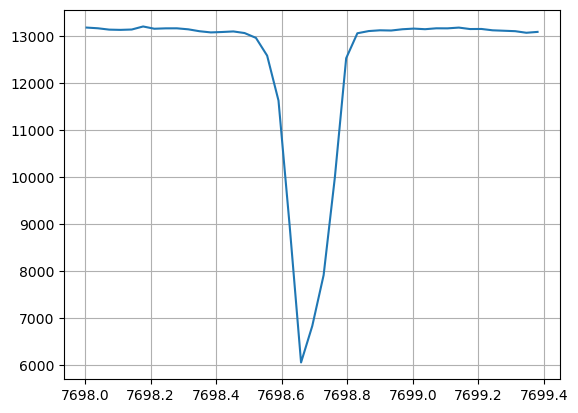

orders/HD170740_2016-06-13T07:24:14_860nm_redl_O13.fits


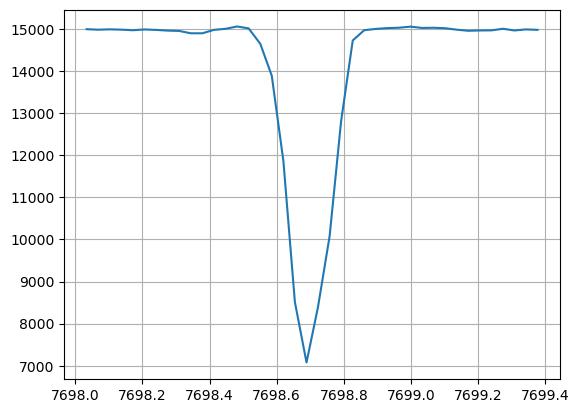

orders/HD170740_2014-09-15T02:50:39_860nm_redl_O13.fits


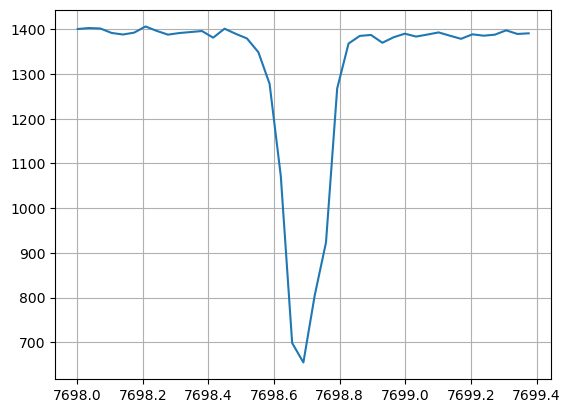

orders/HD170740_2014-09-16T03:15:06_860nm_redl_O13.fits


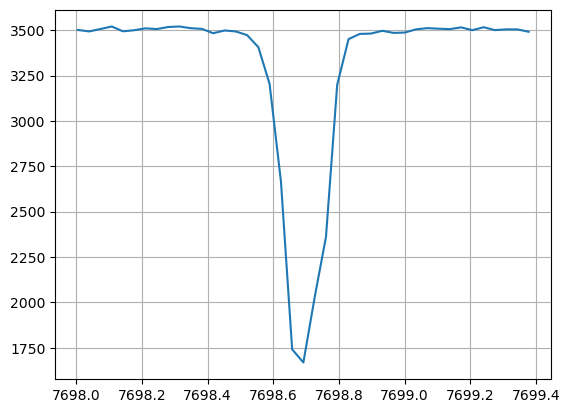

orders/HD170740_2015-06-26T02:05:07_860nm_redl_O13.fits


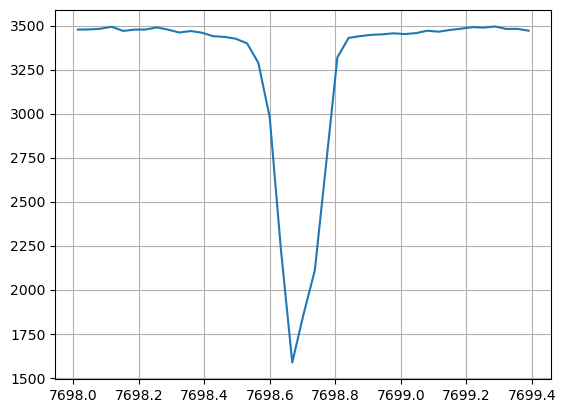

In [162]:
spec_list = []
for file in file_list:
    print(file)
    spec = EdiblesSpectrum(file)
    spec = np.array([spec.bary_wave, spec.c_flux, spec.flux_err])
    spec = crop_spectrum(spec, 7698.0, 7699.4)
    spec_list.append(spec)
    plt.plot(spec[0], spec[1])
    plt.grid()
    plt.show()

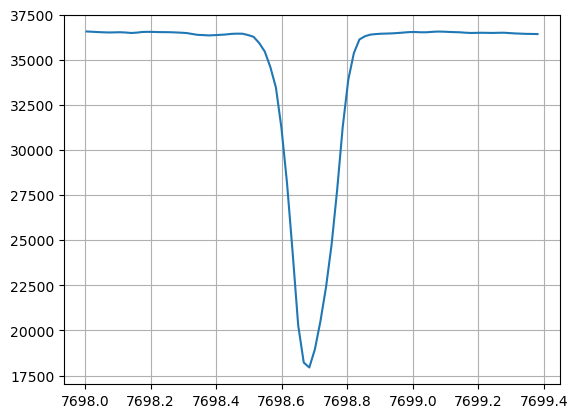

In [163]:
coadd_spec = coadd_spectra(spec_list)

plt.plot(coadd_spec[0], coadd_spec[1])
plt.grid()
plt.show()

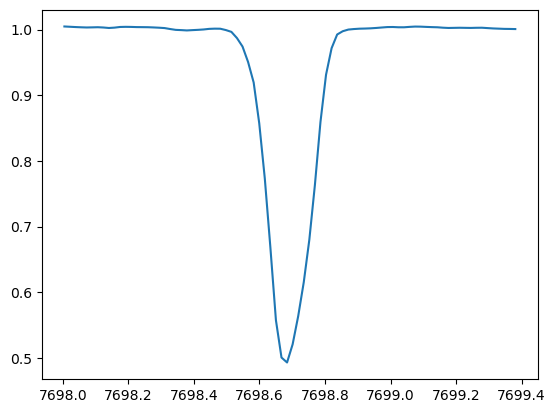

In [164]:
normalize = normalize_spectrum_linear(coadd_spec, cont_1 = np.array([7698.5, 36400]), cont_2 = np.array([7699.6, 36400]))

plt.plot(normalize[0], normalize[1])

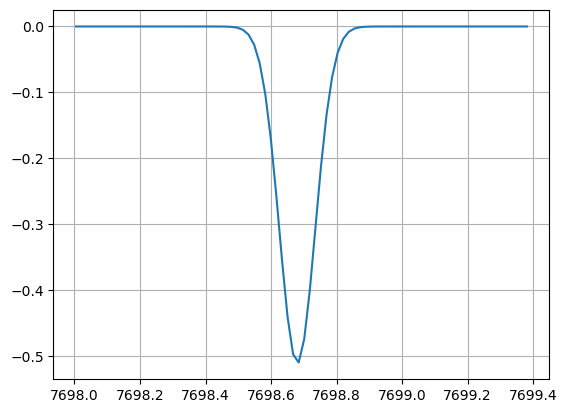

In [165]:
#tau_factor = (N * np.pi * cst.e.esu ** 2 / cst.m_e.cgs / cst.c.cgs * f).value (from voigt_optical_depth)
voigt_depth = voigt_optical_depth(coadd_spec[0], lambda0=7698.68, b=3, N=-4e11, f=target_row.OscillatorStrength, gamma=target_row.Gamma)

plt.plot(coadd_spec[0], voigt_depth)
plt.grid()
plt.show()

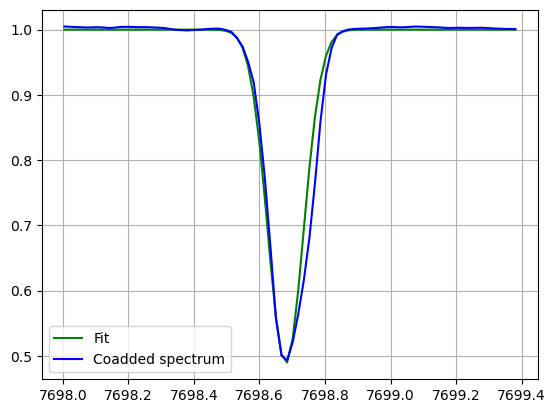

In [166]:
voigt_depth_new = voigt_depth + 1

plt.plot(coadd_spec[0], voigt_depth_new, color='g', label='Fit')
plt.plot(normalize[0], normalize[1], color='b', label='Coadded spectrum')
plt.legend()
plt.grid()

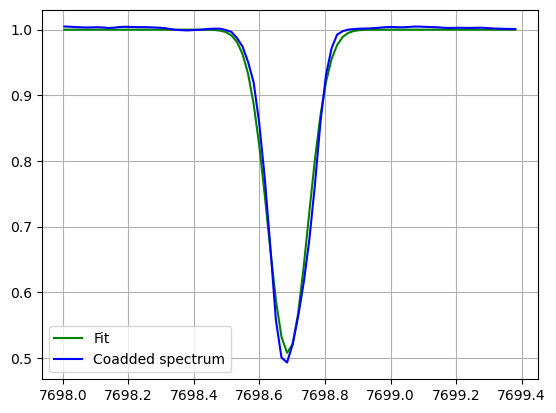

In [190]:
voigt_line = voigt_absorption_line(coadd_spec[0], lambda0=7698.43, f=target_row.OscillatorStrength, gamma=target_row.Gamma, b=1.2, N=1e12, v_rad=5, v_resolution=5, n_step=25, debug=False)

plt.plot(coadd_spec[0], voigt_line, color='g', label='Fit')
plt.plot(normalize[0], normalize[1], color='b', label='Coadded spectrum')
plt.legend()
plt.grid()
